# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [3]:
# importa las librerías
from sklearn.cluster import KMeans
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np

#### 2. Lee las imagenes
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [4]:
# usa imread
# comprueba las dimensiones del numpy array
imagen = imread("ladybug.png")
print(imagen.shape)
print(imagen.dtype)

imagen_original = imagen.shape

(533, 800, 3)
float32


Muestra la imagen para ver que se ha cargado bien

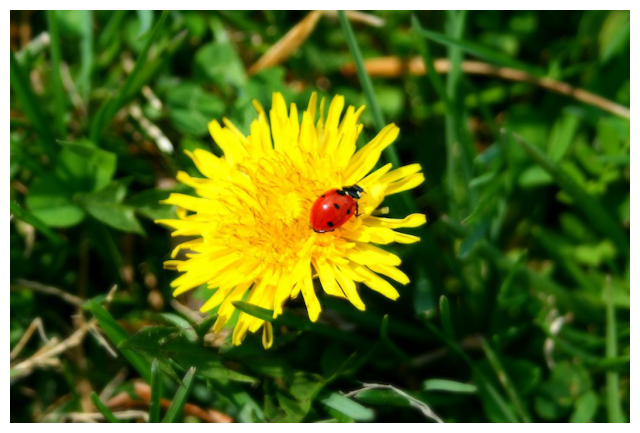

In [5]:
# usa imshow para mostrar la imagen
plt.figure(figsize=(8, 6))
plt.imshow(imagen)
plt.axis('off')
plt.show()

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [6]:
# modifica las dimensiones del numpy array
pixeles = imagen.reshape(-1, 3)
pixeles.shape

(426400, 3)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [7]:
# kmeans con 8 centroides por ejemplo, semilla 42 y 10 repeticiones del kmeans para elegir los centroides que acaban con la mejor inercia
# ajústalo a tus datos

n_colores = 8
kmeans = KMeans(n_clusters=n_colores, random_state=42, n_init=10)
kmeans.fit(pixeles)

print(kmeans.cluster_centers_)
kmeans.inertia_

[[0.09921338 0.25308543 0.0167565 ]
 [0.8781432  0.71907824 0.036368  ]
 [0.37141472 0.5223672  0.15650858]
 [0.98312557 0.9333424  0.02559671]
 [0.21786289 0.38557506 0.057362  ]
 [0.02263677 0.11036167 0.00577073]
 [0.6110979  0.6301077  0.3882831 ]
 [0.7656051  0.19982438 0.04371586]]


3809.608154296875

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizas para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [8]:
# usa las etiquetas a los centroides para segmentar la imagen original
pixeles_segmentados = kmeans.cluster_centers_[kmeans.labels_]
pixeles_segmentados.shape

(426400, 3)

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [9]:
# hay que volver a hacer la imagen rectangular, no una ristra de píxeles
imagen_segmentada = pixeles_segmentados.reshape(imagen_original)
imagen_segmentada.shape

(533, 800, 3)

#### 7. Imprime y guarda en tu ordenador la imagen resultante

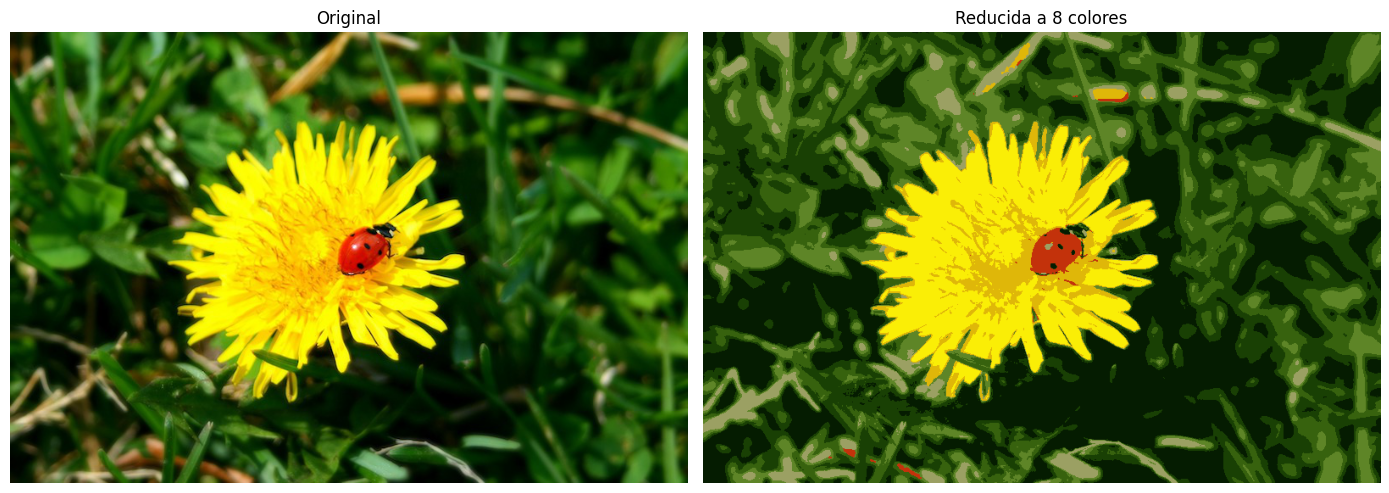

In [10]:
# muestra la imagen modificada
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(imagen)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(imagen_segmentada)
axes[1].set_title(f'Reducida a {n_colores} colores')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('imagen_8_colores.png')
plt.show()

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [4]:
# crea una función que dada una imagen, una cantidad de colores y si se quiere guardar la imagen modificada o solo mostrarla, que siga esos pasos

def reducir_colores(ruta_imagen, n_colores, guardar=False, nombre_salida='salida.png'):
    # 1. Leer
    img = imread(ruta_imagen)

    # Normalizamos el número de canales para que KMeans siempre trabaje con RGB.
    alpha = None
    if img.ndim == 2:
        img_rgb = np.stack([img, img, img], axis=-1)
    elif img.ndim == 3 and img.shape[2] == 4:
        img_rgb = img[:, :, :3]
        alpha = img[:, :, 3:4]
    elif img.ndim == 3 and img.shape[2] >= 3:
        img_rgb = img[:, :, :3]
    else:
        raise ValueError(f'Formato de imagen no soportado: {img.shape}')

    forma = img_rgb.shape

    # 2. Aplanar a tabla de píxeles
    pix = img_rgb.reshape(-1, 3)

    # 3. K-Means
    km = KMeans(n_clusters=n_colores, random_state=42, n_init=10)
    km.fit(pix)

    # 4. Sustituir píxeles por sus centroides
    pix_seg = km.cluster_centers_[km.labels_]

    # 5. Volver a forma rectangular
    img_seg = pix_seg.reshape(forma)
    if alpha is not None:
        img_seg = np.concatenate([img_seg, alpha], axis=2)

    # 6. Mostrar / guardar
    plt.figure(figsize=(8, 6))
    plt.imshow(img_seg)
    plt.axis('off')
    plt.title(f'{n_colores} colores')

    if guardar:
        plt.savefig(nombre_salida, bbox_inches='tight')
        print(f'Guardada en: {nombre_salida}')

    plt.show()
    return img_seg

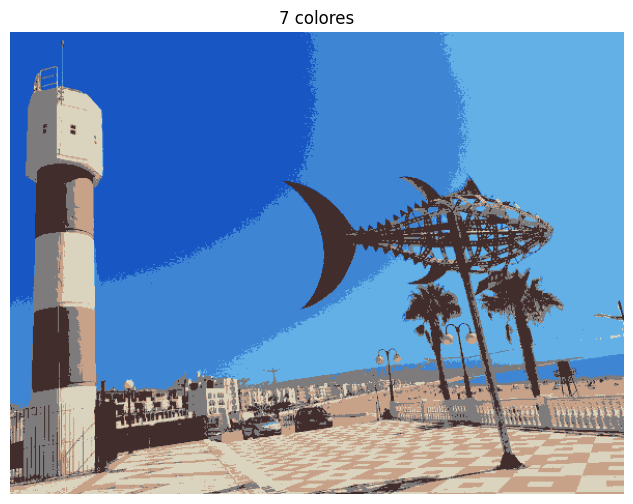

array([[[0.09078893, 0.33943287, 0.76696   , 1.        ],
        [0.09078893, 0.33943287, 0.76696   , 1.        ],
        [0.09078893, 0.33943287, 0.76696   , 1.        ],
        ...,
        [0.38525862, 0.6932998 , 0.9047087 , 1.        ],
        [0.38525862, 0.6932998 , 0.9047087 , 1.        ],
        [0.38525862, 0.6932998 , 0.9047087 , 1.        ]],

       [[0.09078893, 0.33943287, 0.76696   , 1.        ],
        [0.09078893, 0.33943287, 0.76696   , 1.        ],
        [0.09078893, 0.33943287, 0.76696   , 1.        ],
        ...,
        [0.38525862, 0.6932998 , 0.9047087 , 1.        ],
        [0.38525862, 0.6932998 , 0.9047087 , 1.        ],
        [0.38525862, 0.6932998 , 0.9047087 , 1.        ]],

       [[0.09078893, 0.33943287, 0.76696   , 1.        ],
        [0.09078893, 0.33943287, 0.76696   , 1.        ],
        [0.09078893, 0.33943287, 0.76696   , 1.        ],
        ...,
        [0.38525862, 0.6932998 , 0.9047087 , 1.        ],
        [0.38525862, 0.693299

In [5]:
reducir_colores("barbate.png", 7, guardar=False, nombre_salida="salida.png")